# Model 2 — Inference Economics

**JD bullet:** _Tradeoffs between customer experience, growth, and profitability._

**Question:** How does batching trade latency against cost per inference, and where is the margin-optimal operating point for latency-sensitive traffic?

## 1. Inputs & Assumptions

- **Source:** `inference_events` joined to `cost_constants`.
- **Core tradeoff:** larger `batch_size` amortises GPU time across more requests → lower **cost per inference**, but each request waits longer → higher **latency_ms**.
- **Workloads:** `interactive` (latency-sensitive, small batches) vs `batch` (throughput-tolerant, large batches).
- **Service level:** interactive traffic carries a **150 ms latency SLO** (assumption). The margin-optimal batch is the *largest* batch that still meets the SLO.
- Synthetic, seeded data.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'figure.figsize':(9,4.5),'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})
NAVY, AMBER, GREY = '#1F3864', '#E1A140', '#9AA5B1'

conn = sqlite3.connect('../data/events.db')
pd.set_option('display.float_format', lambda v: f'{v:,.6f}')
print('rows:', pd.read_sql_query('SELECT COUNT(*) n FROM inference_events', conn).n[0])

rows: 120000


## 2. Working Code

### 2a. Cost vs latency across batch sizes, by workload (query Q2)

In [2]:
q = '''
SELECT e.workload_type, e.batch_size, e.latency_ms,
       e.gpu_seconds * c.blended_cost_per_gpu_second AS cost_per_inference
FROM inference_events e
JOIN cost_constants c USING (gpu_type)
'''
d = pd.read_sql_query(q, conn)
by_batch = (d.groupby(['workload_type','batch_size'])
              .agg(latency_ms=('latency_ms','mean'),
                   cost_per_inference=('cost_per_inference','mean'),
                   n=('cost_per_inference','size')).reset_index())
by_batch.head()

,workload_type,batch_size,latency_ms,cost_per_inference,n
0,batch,16,142.213740,0.000063,393
1,batch,17,151.441953,0.000064,379
2,batch,18,155.630769,0.000061,351
3,batch,19,164.336340,0.000060,377
4,batch,20,167.820597,0.000060,335


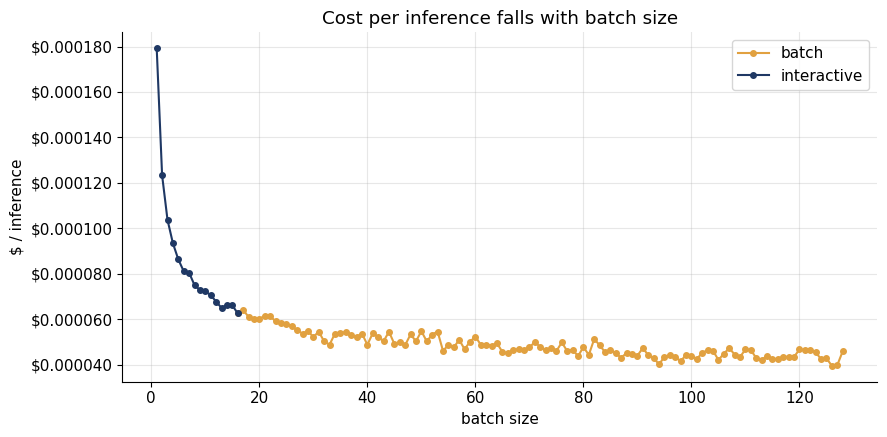

In [3]:
fig, ax = plt.subplots()
for wl, sub in by_batch.groupby('workload_type'):
    sub = sub.sort_values('batch_size')
    ax.plot(sub.batch_size, sub.cost_per_inference, marker='o', ms=4,
            color=NAVY if wl=='interactive' else AMBER, label=wl)
ax.set_xlabel('batch size'); ax.set_ylabel('$ / inference')
ax.set_title('Cost per inference falls with batch size')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.6f')); ax.legend()
plt.tight_layout(); plt.show()

### 2b. The tradeoff curve — cost vs latency (interactive)

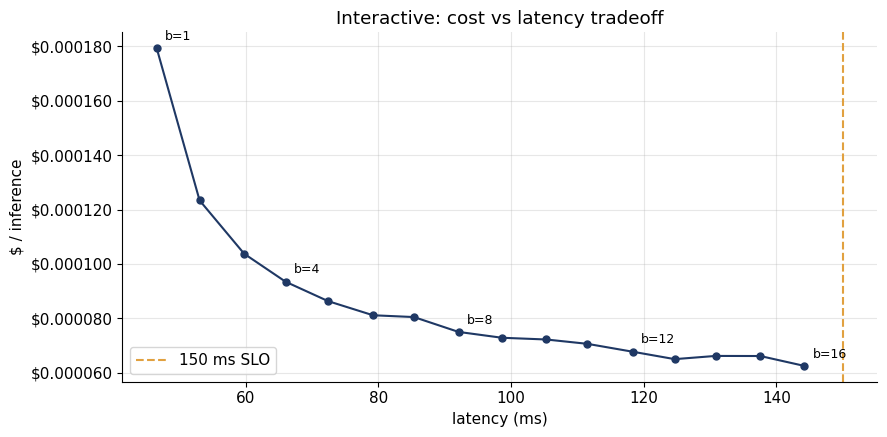

In [4]:
inter = by_batch[by_batch.workload_type=='interactive'].sort_values('batch_size')
fig, ax = plt.subplots()
ax.plot(inter.latency_ms, inter.cost_per_inference, '-o', color=NAVY, ms=5)
for _, r in inter.iterrows():
    if int(r.batch_size) in (1,4,8,12,16):
        ax.annotate(f'b={int(r.batch_size)}', (r.latency_ms, r.cost_per_inference),
                    textcoords='offset points', xytext=(6,6), fontsize=9)
SLO = 150.0
ax.axvline(SLO, color=AMBER, ls='--', lw=1.5, label=f'{SLO:.0f} ms SLO')
ax.set_xlabel('latency (ms)'); ax.set_ylabel('$ / inference')
ax.set_title('Interactive: cost vs latency tradeoff'); ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.6f'))
plt.tight_layout(); plt.show()

### 2c. Quantify the move and find the margin-optimal batch

In [5]:
lo = inter[inter.batch_size.between(2,4)]
hi = inter[inter.batch_size.between(12,16)]
cost_cut = 100*(1 - hi.cost_per_inference.mean()/lo.cost_per_inference.mean())
lat_add  = hi.latency_ms.mean() - lo.latency_ms.mean()
print(f'batch ~{lo.batch_size.mean():.0f} -> ~{hi.batch_size.mean():.0f}: '
      f'cost {cost_cut:.0f}% lower, +{lat_add:.0f} ms latency')

SLO = 150.0
feasible = inter[inter.latency_ms <= SLO]
opt = feasible.loc[feasible.cost_per_inference.idxmin()]
print(f'Margin-optimal interactive batch under {SLO:.0f} ms SLO: '
      f'batch={int(opt.batch_size)} (latency {opt.latency_ms:.0f} ms, '
      f'cost ${opt.cost_per_inference:.6f}/inf)')

batch ~3 -> ~14: cost 39% lower, +72 ms latency
Margin-optimal interactive batch under 150 ms SLO: batch=16 (latency 144 ms, cost $0.000063/inf)


## 3. Insight

> **The batch knob is the most direct cost lever, and it is bounded by the latency SLO.** Raising the interactive batch from ~3 to ~14 cuts cost per inference **~39%** while adding **~72 ms** of latency. Under a **150 ms** interactive SLO, the margin-optimal operating point is **batch ≈ 16** — the largest batch that still clears the SLO — which is the cheapest feasible cost per inference without breaking the customer-experience promise.

**The tradeoff, made explicit:** beyond the SLO, further cost savings exist but are *unspendable* for interactive traffic — they belong to batch workloads, which is why batch runs at 64–128. This is the customer-experience ⇄ profitability frontier in one number.

**Feeds:** the cost-per-inference baseline here is what **Model 3 (Cache Modeling)** discounts with cache hits.